# PCB1 A2: explain the misses before changing the detector

## Findings

Scratch and melt are the weakest source-labeled groups. The largest annotation quartile is easier than the smaller groups. Retrospective threshold movement can recover 10 additional anomalies with the same nine observed false alarms, but misses also have poor localization. Normal-score shift and cross-location matching are not established causes.

**PCB1 is development data.** This notebook reads the saved A2 tables and charts; it does not run a detector or select an operational threshold. The first pilot is preserved and PCB2 remains sealed. See `artifacts/pcb1_a2/diagnostic_summary.md` for the seven diagnostic questions and `docs/improvement_plan_review.md` for corrections to the proposed plan.

In [1]:
from pathlib import Path
import json,hashlib
import pandas as pd
from IPython.display import display,Image,Markdown
root=Path.cwd()
if root.name=='notebooks':root=root.parent
folder=root/'artifacts/pcb1_a2'
metadata=json.loads((folder/'diagnostics_metadata.json').read_text())
for name,expected in metadata['outputs'].items():
    assert hashlib.sha256((folder/name).read_bytes()).hexdigest()==expected
verification=json.loads((folder/'verification_a2.json').read_text())
assert verification['passed'] and verification['no_model_inference']
print('Original run:',metadata['run_id'],'; anomaly images:',metadata['anomaly_images'],'; multi-label images:',metadata['multi_label_images'])

Original run: 31e0704ff1da6906 ; anomaly images: 100 ; multi-label images: 9


## Threshold placement and ranking

These are retrospective **best attainable** operating points within an FPR budget, chosen from all saved labeled PCB1 scores. Tied scores enter together, using strict `score > threshold`. They are not normal-only calibrated settings or fresh validation. The original operating point is 43/100 anomalies and 9/100 normal false alarms.

,target_fpr,threshold,recall,realized_fpr,true_positives,false_negatives,false_positives,true_negatives
0,0.01,2.66480,0.24,0.01,24,76,1,99
1,0.02,2.58067,0.27,0.02,27,73,2,98
2,0.05,2.44957,0.35,0.05,35,65,5,95
3,0.10,2.36425,0.53,0.09,53,47,9,91
4,0.20,2.28819,0.73,0.19,73,27,19,81


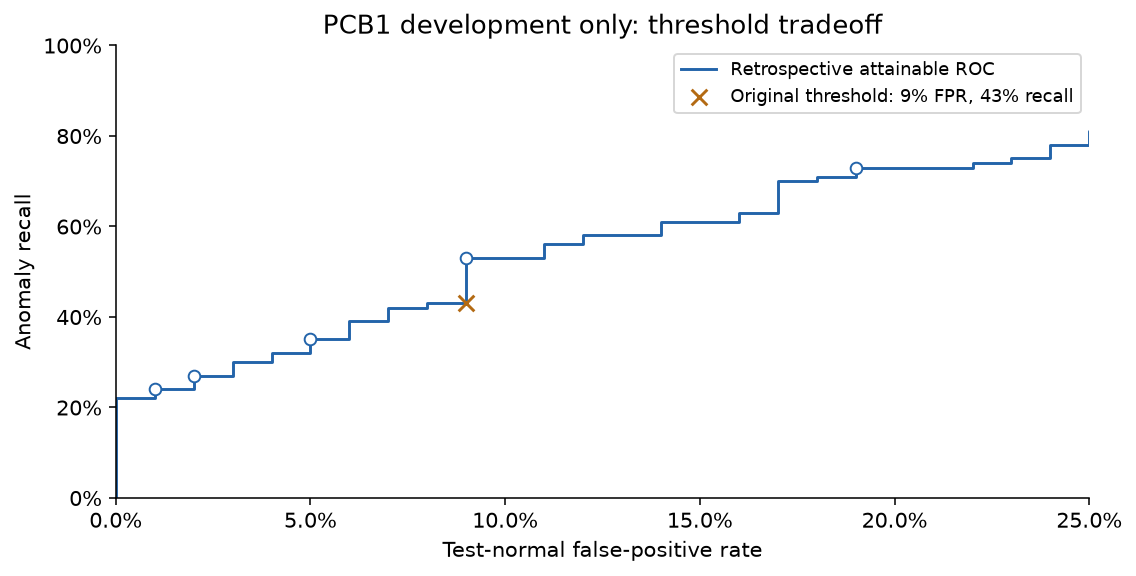

In [2]:
operating=pd.read_csv(folder/'recall_vs_fpr.csv')
display(operating.round(5))
display(Image(filename=str(folder/'recall_vs_fpr.png')))

## Source defect labels and localization

Nine multi-label images contribute to 110 memberships. An image appears once in every named source group. Localization uses its union mask, so a grouped value is not the isolated quality of a specific component defect. “Missing” performs substantially better than “scratch” and “melt” in this run.

,defect_type,sample_count,detected_count,missed_count,recall,median_per_image_pixel_ap,peak_inside_mask_rate
0,bent,15,12,3,0.8000,0.2108,0.4667
1,melt,54,19,35,0.3519,0.0174,0.1111
2,missing,20,14,6,0.7000,0.9393,0.6500
3,scratch,21,3,18,0.1429,0.0160,0.1905


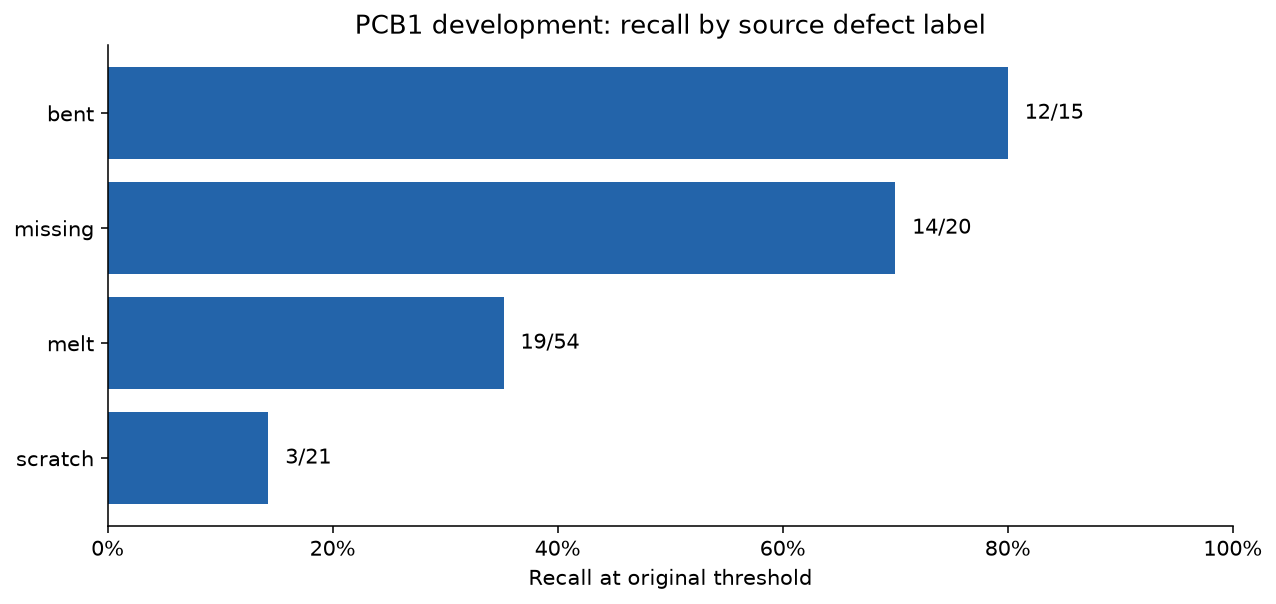

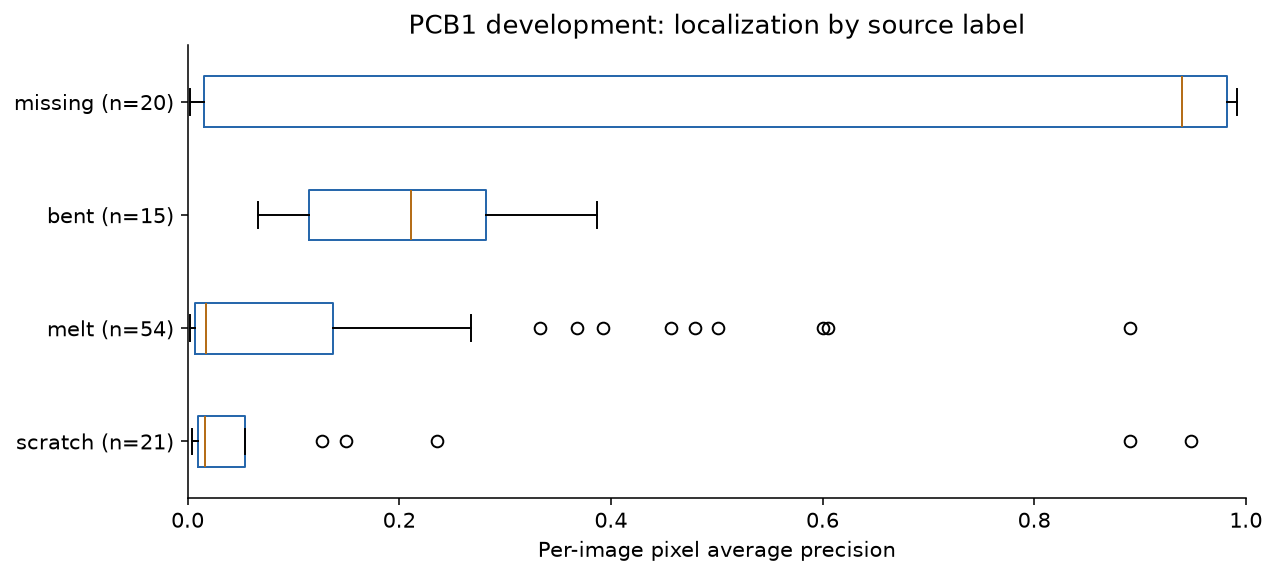

In [3]:
types=pd.read_csv(folder/'recall_by_defect_type.csv')
display(types[['defect_type','sample_count','detected_count','missed_count','recall','median_per_image_pixel_ap','peak_inside_mask_rate']].round(4))
display(Image(filename=str(folder/'recall_by_defect_type.png')))
display(Image(filename=str(folder/'pixel_ap_by_defect_type.png')))

## Annotation size

Quartile boundaries retain equal-area ties together, giving 27/24/25/24 images. Geometry is the original 256-square mask/map resolution. Association between size and score does not isolate resize loss from defect type, memory coverage or feature sensitivity.

,size_quartile,sample_count,detected_count,missed_count,recall,mask_area_fraction_min,mask_area_fraction_max,median_image_anomaly_score,median_score_minus_threshold,median_per_image_pixel_ap,peak_inside_mask_rate,overlap_rate
0,Q1,27,9,18,0.33333,0.00079,0.00150,2.33269,-0.06738,0.00790,0.03704,0.62963
1,Q2,24,7,17,0.29167,0.00156,0.00200,2.35928,-0.04079,0.01647,0.12500,0.70833
2,Q3,25,10,15,0.40000,0.00201,0.00314,2.33663,-0.06344,0.04096,0.24000,0.84000
3,Q4,24,17,7,0.70833,0.00349,0.12723,3.09218,0.69211,0.76347,0.66667,1.00000


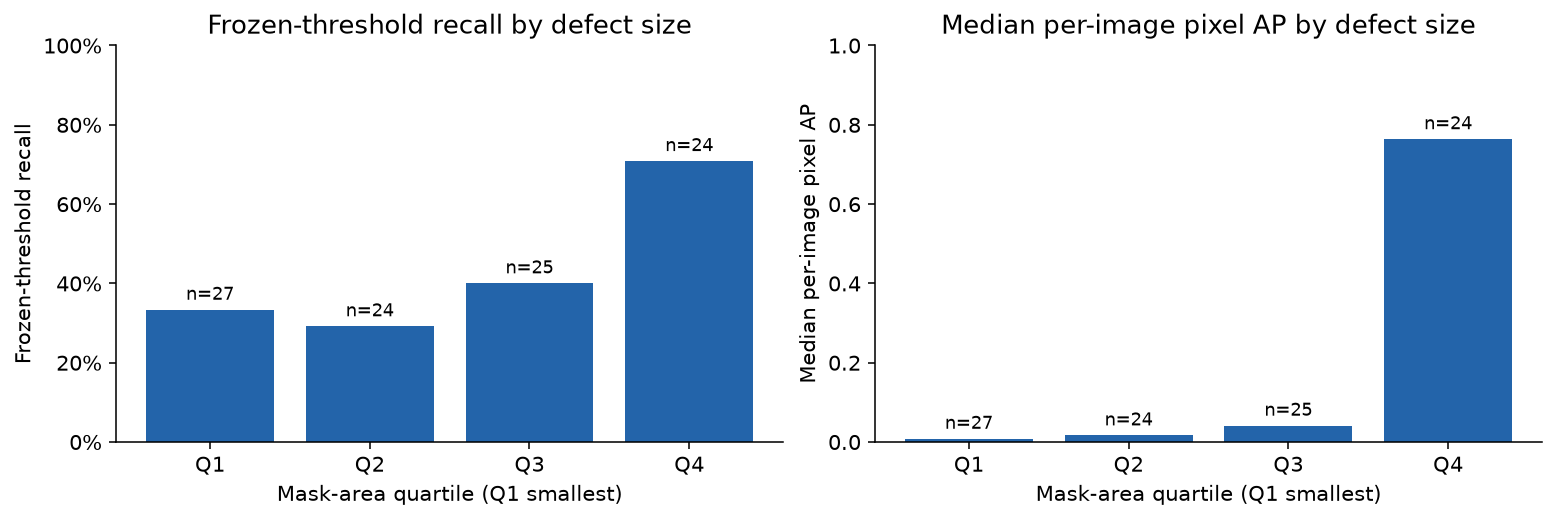

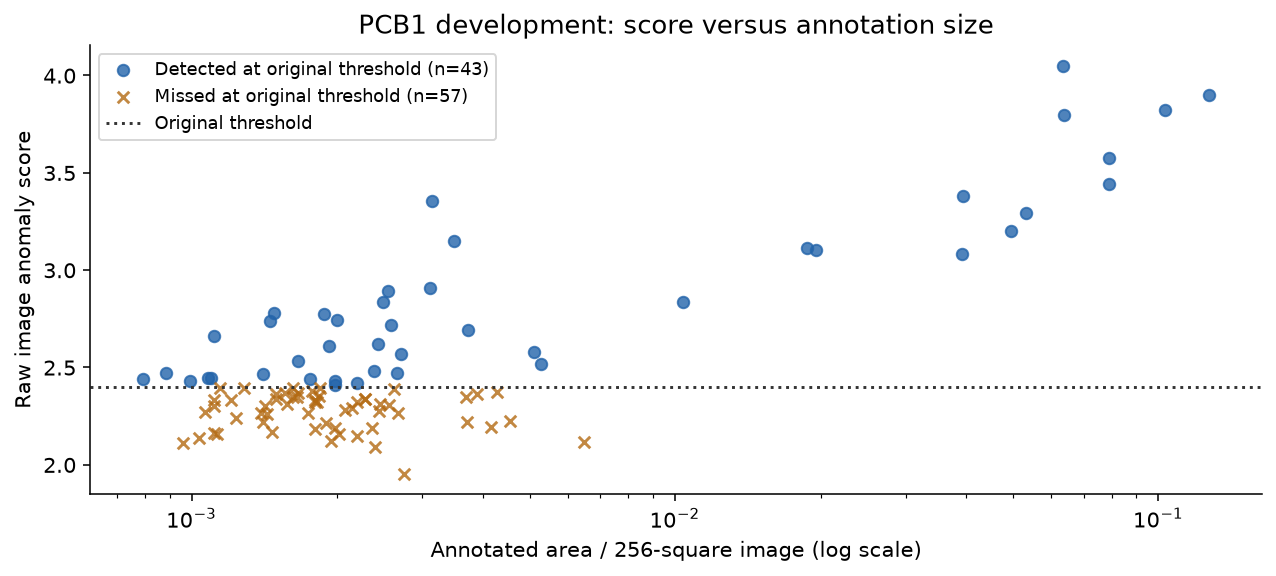

In [4]:
quartiles=pd.read_csv(folder/'recall_by_defect_size_quartile.csv')
display(quartiles.round(5))
display(Image(filename=str(folder/'recall_by_defect_size_quartile.png')))
display(Image(filename=str(folder/'score_vs_defect_area.png')))

## Normal-score uncertainty

Calibration scores have somewhat lower observed medians/tails. With 100 test normals, 9 false alarms give a Wilson 95% interval of approximately 4.8–16.2% under independent-image assumptions; physical-object independence remains unverified. The KS result does not establish a shift and also does not prove equivalence. Finite normal calibration adds uncertainty to the threshold itself.

,split,count,mean,median,standard_deviation,p90,p95,p99,fraction_above_frozen_threshold
0,calibration,181,2.06181,1.99975,0.17729,2.33734,2.40007,2.49468,0.04972
1,test,100,2.09635,2.05278,0.20629,2.36307,2.45086,2.66538,0.09000


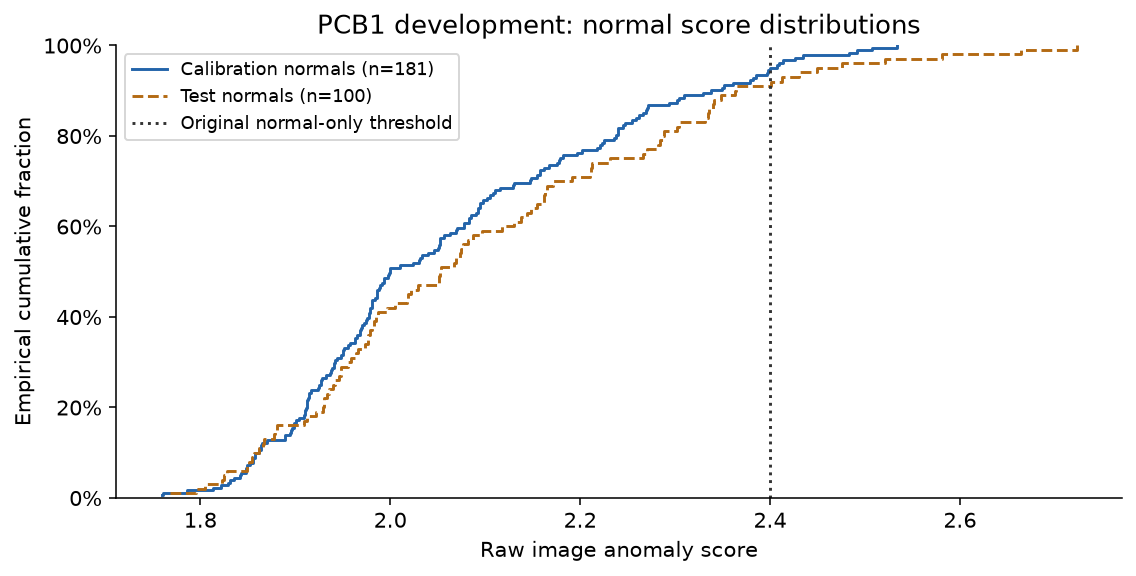

,detected_at_frozen_threshold,image_count,median_pixel_ap,peak_inside_mask_rate,any_overlap_rate
0,False,57,0.0099,0.0526,0.6316
1,True,43,0.3509,0.5349,1.0000


Observed KS distance: 0.1019


In [5]:
display(pd.read_csv(folder/'normal_score_distribution.csv').round(5))
display(Image(filename=str(folder/'normal_score_distribution.png')))
uncertainty=json.loads((folder/'association_uncertainty.json').read_text())
display(pd.DataFrame(uncertainty['detection_localization_groups']).round(4))
print('Observed KS distance:',round(uncertainty['calibration_test_normal_ks']['statistic'],4))

## Saved nearest-reference locations

Offsets come from maximum-score query patches on an **unregistered** 32-square feature grid. A missed defect may be elsewhere than that winning patch; source rotation and translation can also produce offsets. Larger offsets occur in 15/57 misses versus 19/43 true positives, so the saved traces do not prioritize spatial restriction as the first fix.

In [6]:
display(pd.read_csv(folder/'trace_by_outcome.csv').round(4))

,outcome,n_traces,median_offset_cells,p90_offset_cells,outside_radius_0_count,outside_radius_0_rate,outside_radius_1_count,outside_radius_1_rate,outside_radius_2_count,outside_radius_2_rate,outside_radius_4_count,outside_radius_4_rate,outside_radius_8_count,outside_radius_8_rate
0,FN,57,1.0,13.0,52,0.9123,24,0.4211,15,0.2632,11,0.1930,10,0.1754
1,FP,9,5.0,13.0,8,0.8889,6,0.6667,5,0.5556,5,0.5556,3,0.3333
2,TN,91,1.0,13.0,72,0.7912,29,0.3187,22,0.2418,21,0.2308,21,0.2308
3,TP,43,2.0,12.8,41,0.9535,27,0.6279,19,0.4419,12,0.2791,9,0.2093


## Systematic qualitative review

Selection rules include strong/weak-localized true positives, just-below/low-score misses, the smallest area quartile, every source type, and representative normal false positives. Selection IDs and reasons are saved. Raw map scale and original thresholds are shared. Cyan contours are retrospective source masks.

,image_id,reasons
0,de611bce473c840af8adafcd,"[""TP: strongest per-image localization""]"
1,ca6517206c7ed606f1334b73,"[""TP: weakest per-image localization""]"
2,d974322eff775a646b101f0e,"[""FN: nearest below image threshold""]"
3,ef6143041222529aa5aaae7c,"[""FN: lowest image score""]"
4,d513967cbf2cbf166191b214,"[""Smallest-area quartile""]"
5,d9a35e62add18f84d5fe6ab2,"[""bent: middle score-ranked image""]"
6,cf0b7d2b92f0fb2e900016bc,"[""melt: middle score-ranked image""]"
7,f8c75b3d35149a713c6f9194,"[""missing: middle score-ranked image""]"
8,06a000c3b7f783f28804f8a4,"[""scratch: middle score-ranked image""]"
9,122c351f4783e562322ae0b4,"[""FP: middle score-ranked normal""]"


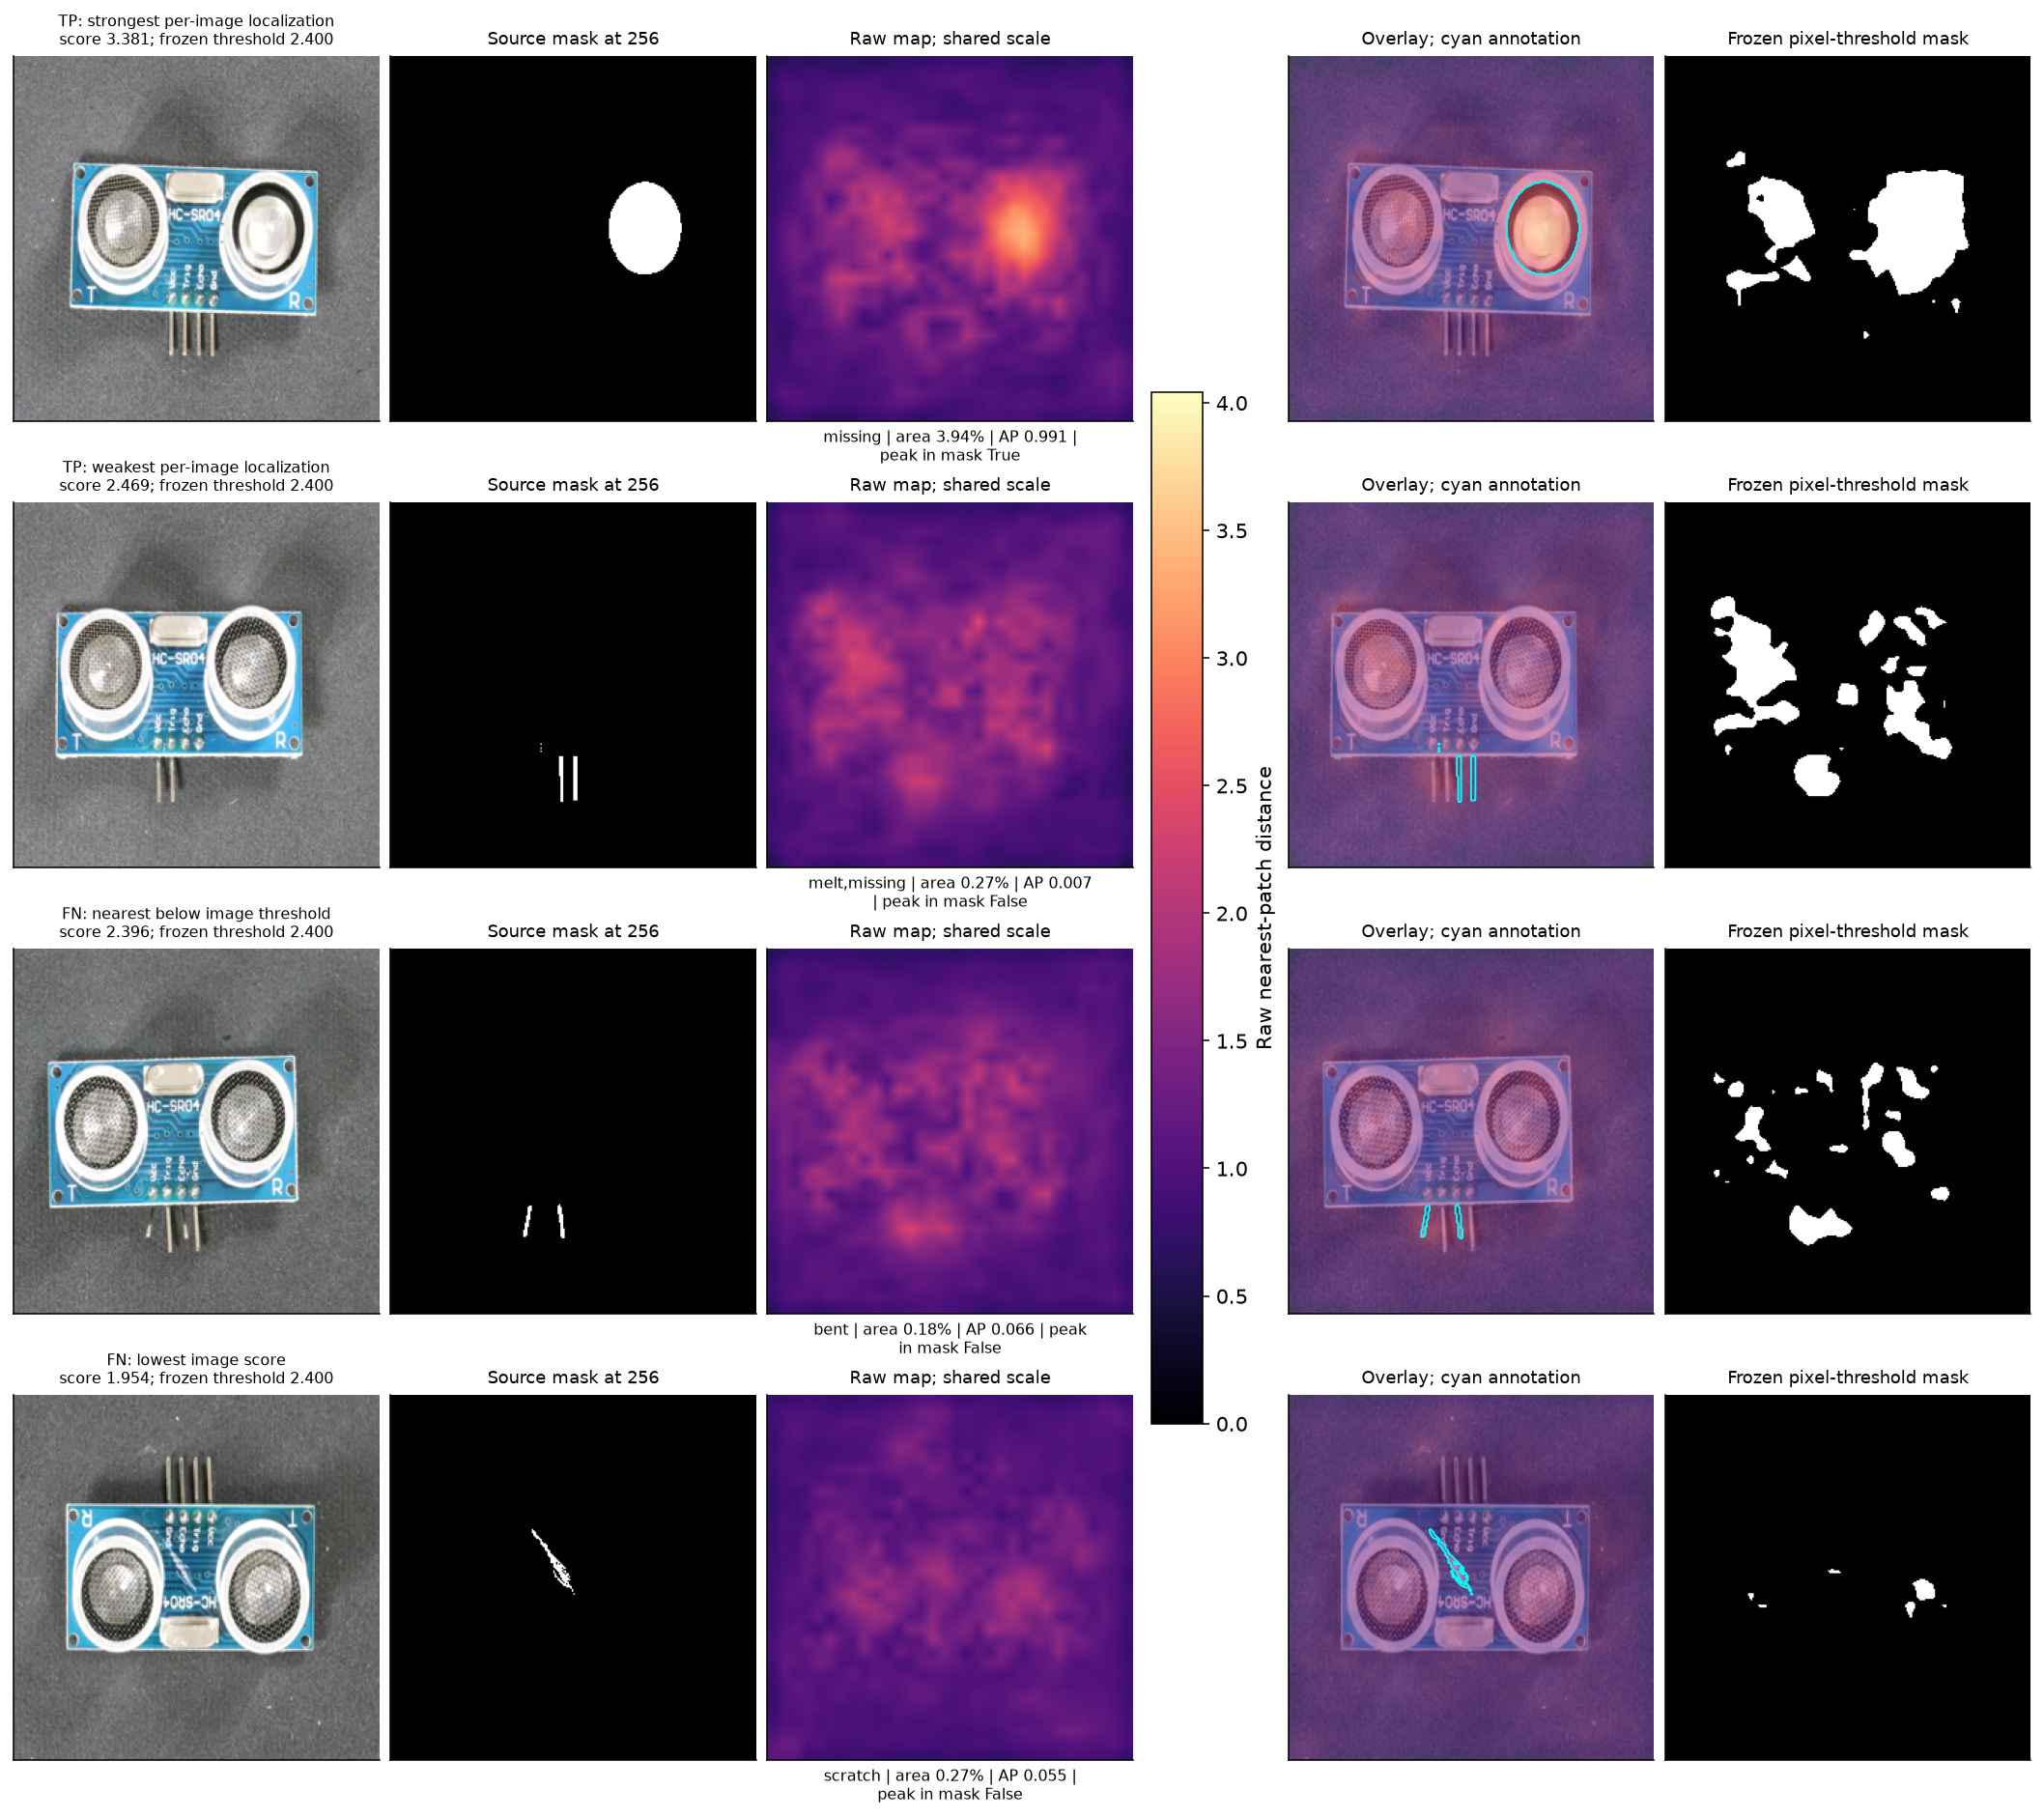

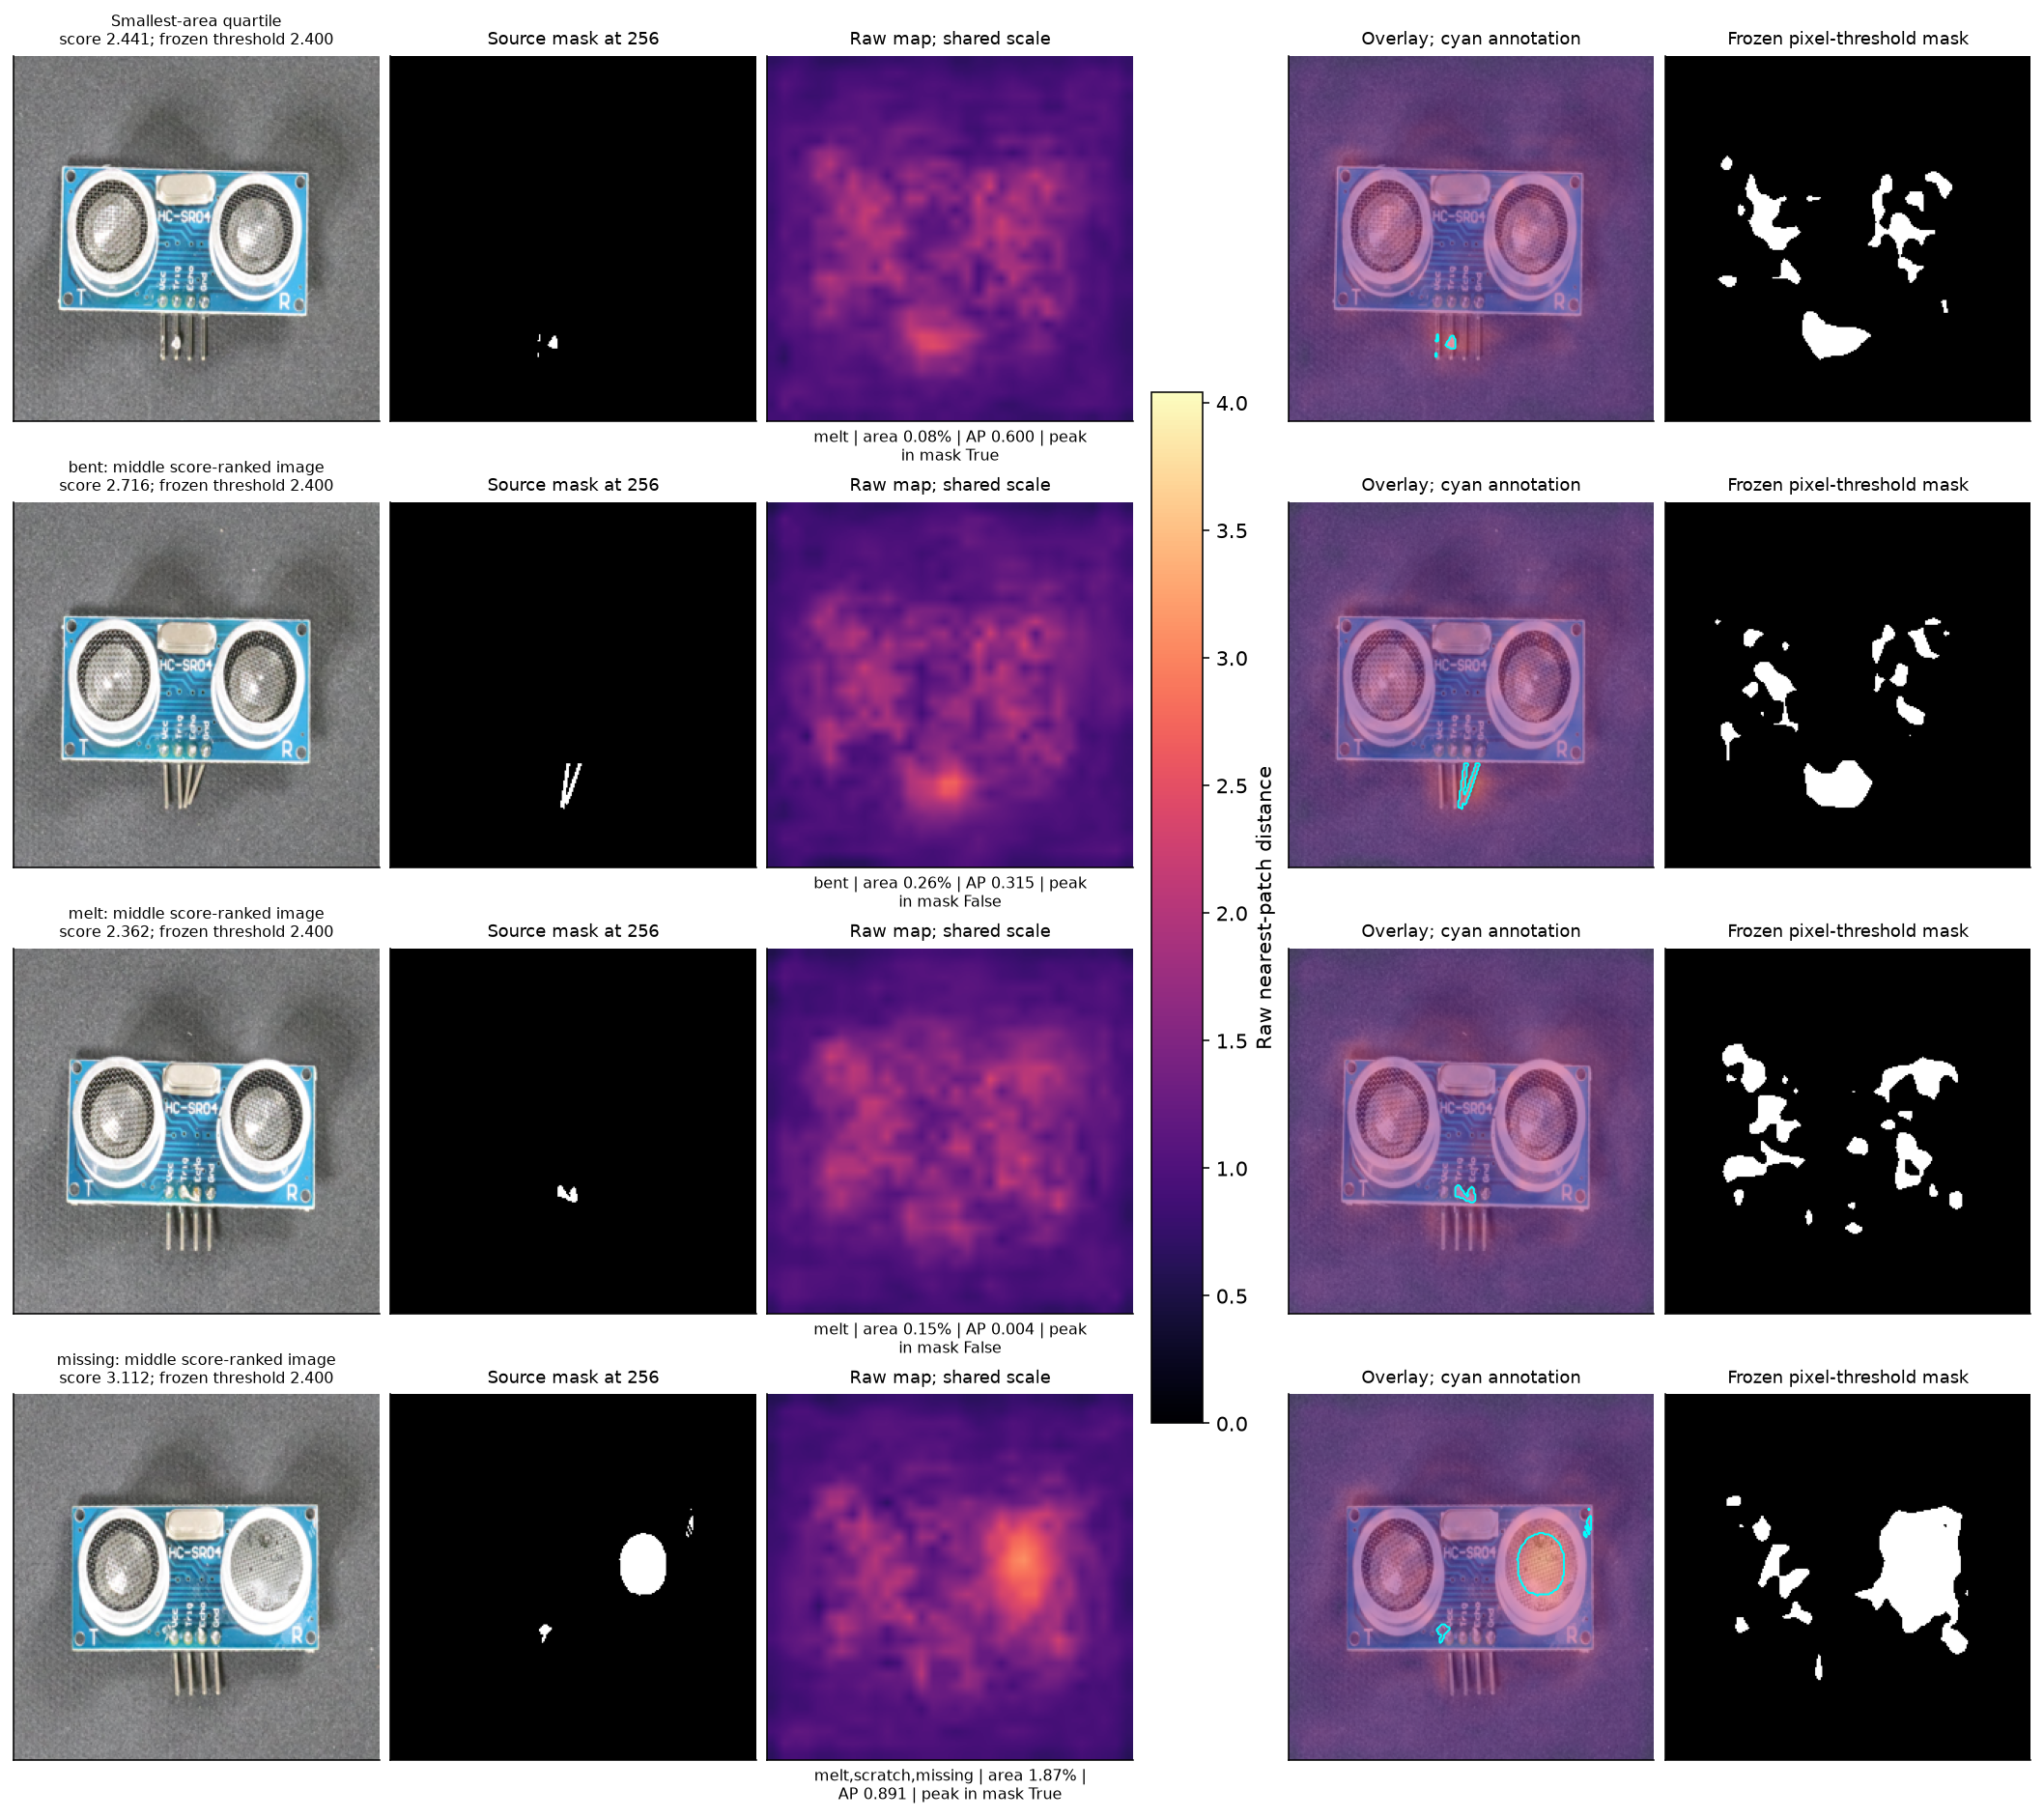

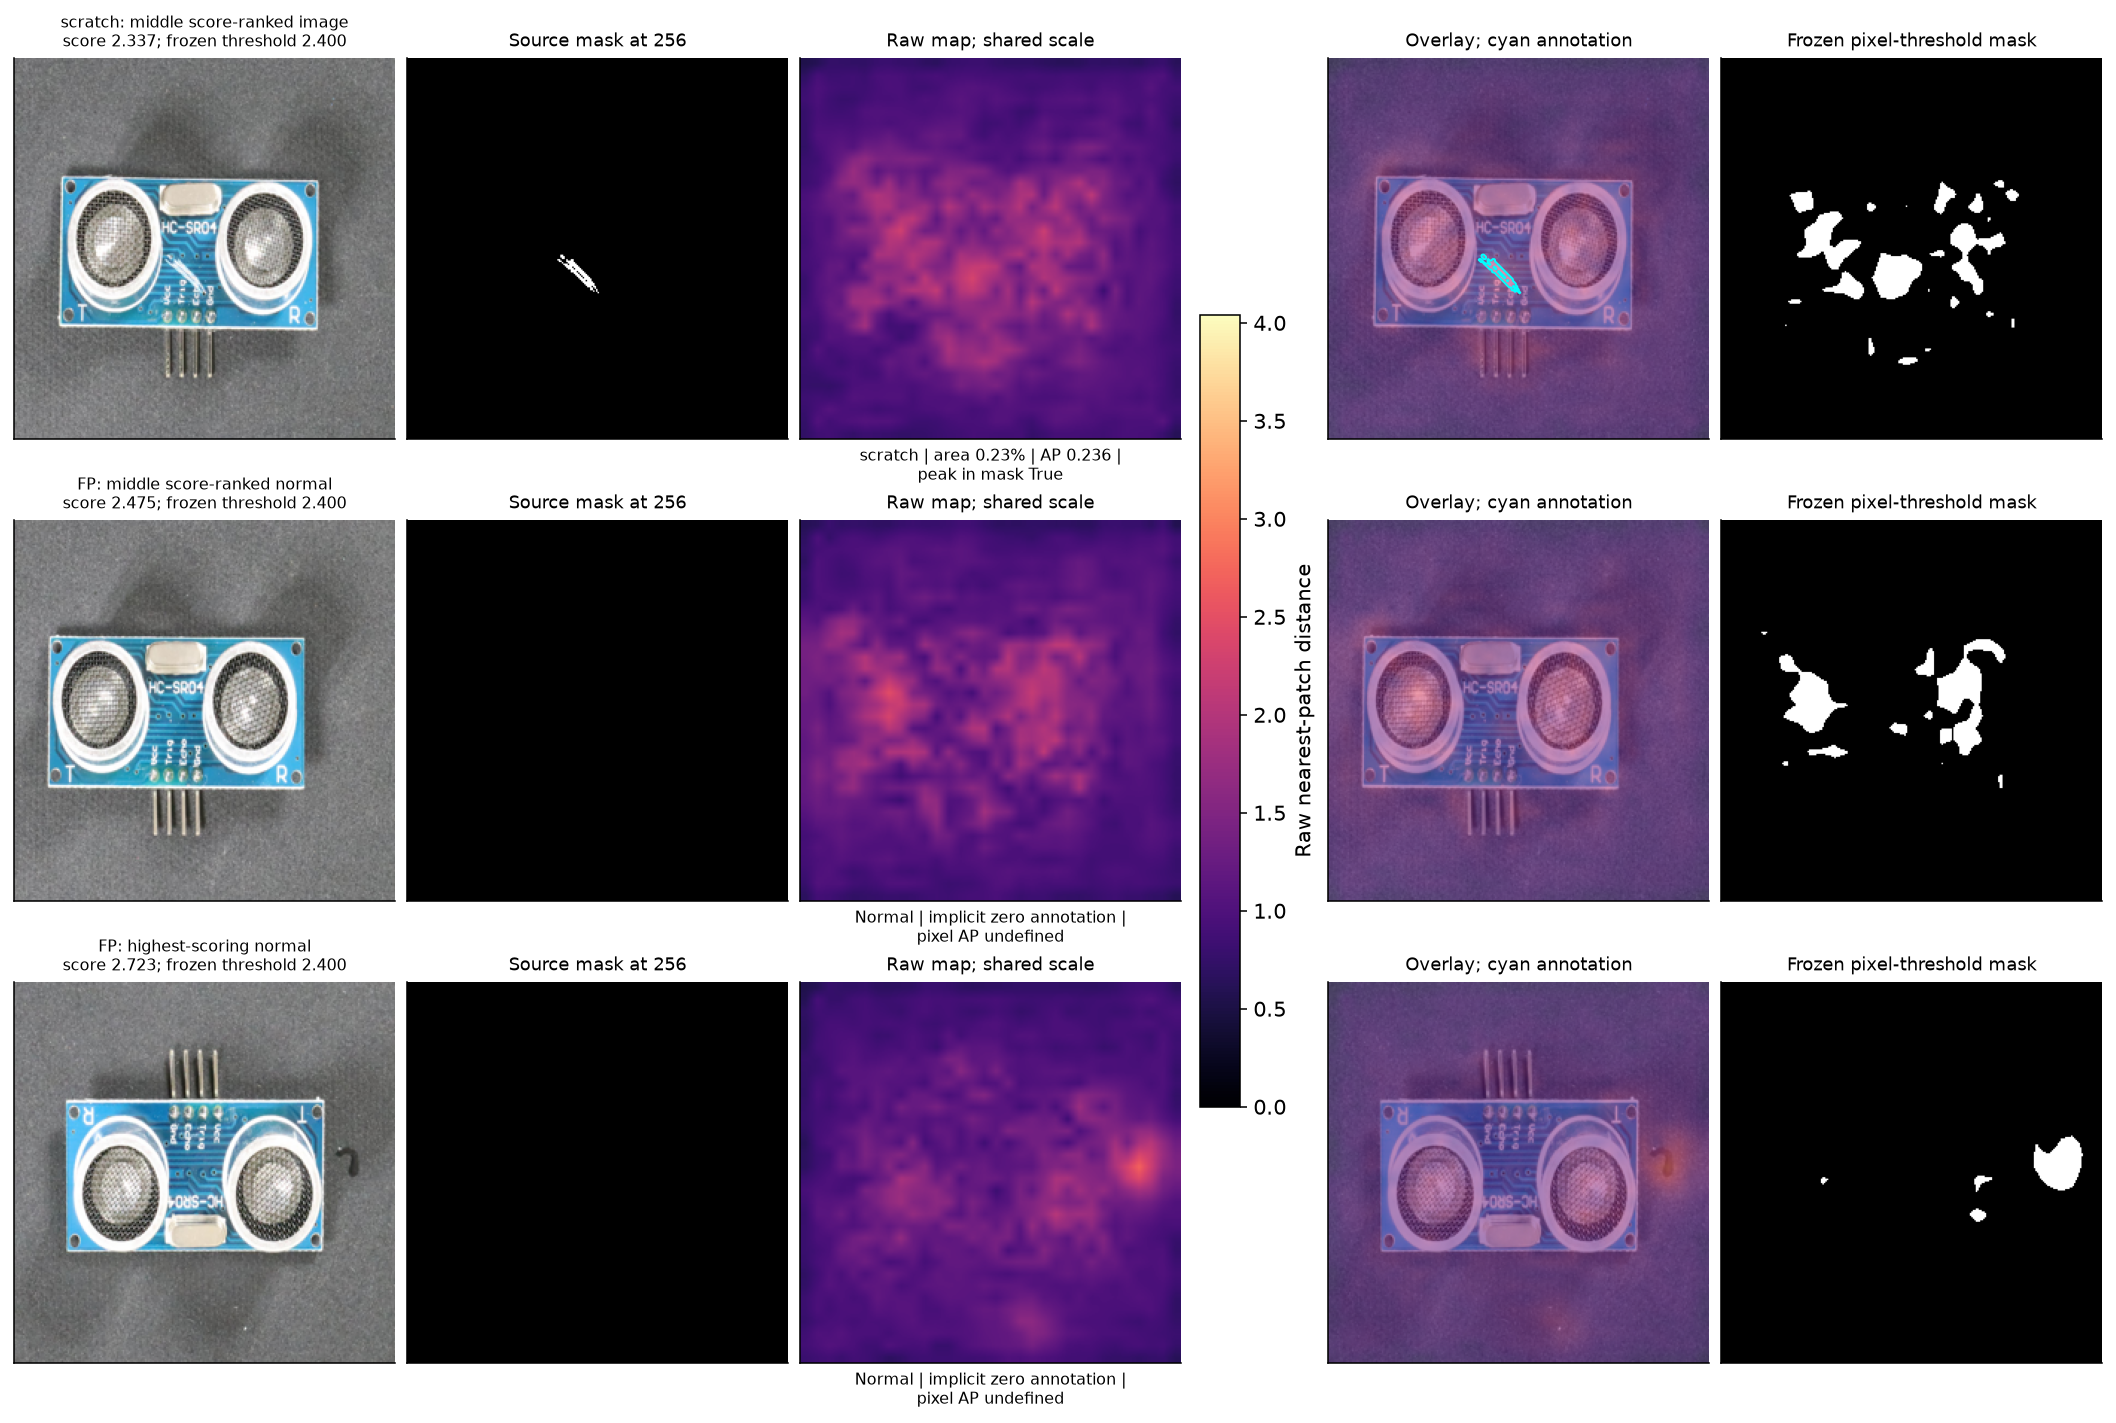

In [7]:
display(pd.read_csv(folder/'qualitative/selection.csv'))
for page in sorted((folder/'qualitative').glob('contact_sheet_*.png')):
    display(Image(filename=str(page)))

## Next bounded experiments

First validate a fitting-normal-derived board crop, aspect preservation, orientation and inverse transforms. Then isolate geometry at 256 and resolution at 512 with the same ResNet18/memory/scoring/normal-calibration rule. Compare coreset selection at matched counts before increasing memory or replacing the backbone. The naive WideResNet 512 feature bank exceeds the current RAM budget; use an explicit resource smoke and cap.

These candidates have not been executed and no performance gain is claimed. Registration is a testable prerequisite for spatial matching, not a guaranteed improvement. Freeze the full selected recipe before the first PCB2 confirmation; category-specific normal fitting is not zero-shot transfer.